In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import globals as gl
from Pcm import find_model, calc_normalized_likelihood_in_parcel, get_likelihood_in_parcel
import PcmPy as pcm
import pickle
from scipy.stats import ttest_1samp
from matplotlib.patches import ConnectionPatch, Rectangle
from matplotlib import colormaps as cm
from Plot import add_significant_patches_to_ml_rois, add_lineplot_to_boxplot, set_spines_and_ticks_width, add_noise_ceiling

plt.style.use('default')

Base directory found: /cifs/diedrichsen/data/SensoriMotorPrediction/
Base directory: /cifs/diedrichsen/data/SensoriMotorPrediction/


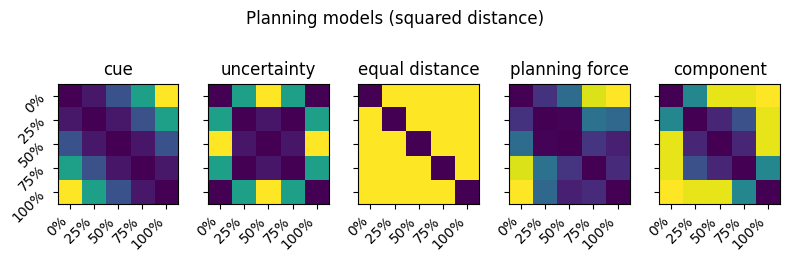

In [7]:
experiment = 'smp2'
glm = 12

f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'M.plan.glm{glm}.pkl'), 'rb')
M = pickle.load(f)

vmin, vmax=-4, 4

D, name = [], []
for m in M:
    if isinstance(m, pcm.FixedModel) & (m.name != 'null'):
        D.append(pcm.G_to_dist(m.G))
        name.append(m.name)
    if isinstance(m, pcm.ComponentModel):
        D.append(pcm.G_to_dist(m.Gc.sum(axis=0)))
        name.append(m.name)

fig, axs = plt.subplots(1, len(D), sharex=True, sharey=True, figsize=(8, 2.5))

for ax, d, n in zip(axs, D, name ):
    # d = np.sign(d) * np.sqrt(np.abs(d))
    ax.imshow(d, )
    ax.set_title(n)

    ax.set_xticks(np.arange(5))
    ax.set_xticklabels(list(gl.regressor_mapping.keys())[:5], rotation=45, ha='right')
    ax.set_yticks(np.arange(5))
    ax.set_yticklabels(list(gl.regressor_mapping.keys())[:5], rotation=45, ha='right')

fig.suptitle('Planning models (squared distance)')
fig.tight_layout()

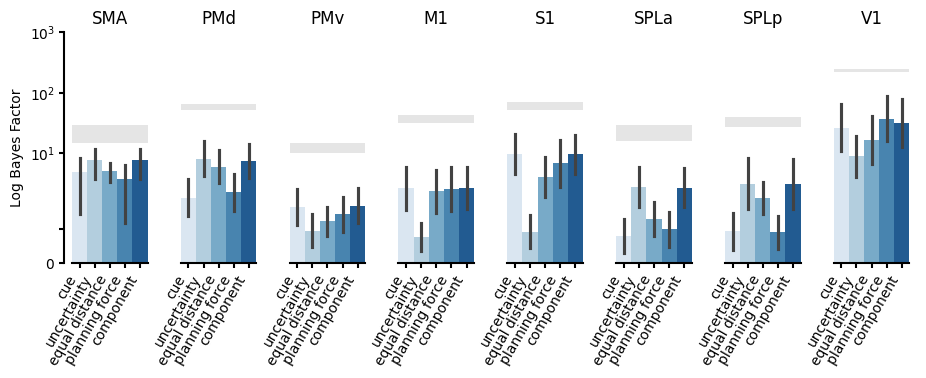

In [8]:
rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']
glm = 14
Hem = 'L'
experiment = 'smp2'

fig, axs = plt.subplots(1, len(rois), figsize=(11, 3), sharex=True, sharey=True)

LL = pd.DataFrame()
for r, roi in enumerate(rois):

    T_cv = pd.read_pickle(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T_cv.plan.glm{glm}.{Hem}.{roi}.pkl'))
    T_gr = pd.read_pickle(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T_gr.plan.glm{glm}.{Hem}.{roi}.pkl'))

    plt.sca(axs[r])
    ax = pcm.model_plot(T_cv.likelihood,
                    null_model = 'null',
                    noise_ceiling= 'ceil',
                    upper_ceiling = T_gr.likelihood['ceil'],
                    width=1,
                    palette='Blues',
                    errorbar='se')
    ax.set_title(roi)
    ax.set_xlabel('')
    ax.set_yscale('symlog')
    ax.spines[['bottom',]].set_bounds(-.5, 4.5)
    ax.spines[['left',]].set_bounds(0, 10**3)
    ax.set_yticks([0, 10, 100, 1000])
    ax.set_xlim(-1, 5)
    ax.set_xticks(ax.get_xticks())
    ax.set_xticklabels(ax.get_xticklabels(), rotation=60, ha='right')

    if r == 0:
        ax.spines[['top', 'right',]].set_visible(False)
        set_spines_and_ticks_width(ax, spine_width=1.5,spine_sides=('left', 'bottom',), tick_width=1.5,axes=('x', 'y'),which='both')
    else:
        ax.spines[['top', 'right','left']].set_visible(False)
        set_spines_and_ticks_width(ax, tick_width=0, axes='y')
        set_spines_and_ticks_width(ax, spine_width=1.5,spine_sides=('bottom',), tick_width=1.5,axes='x',which='both')

plt.show()

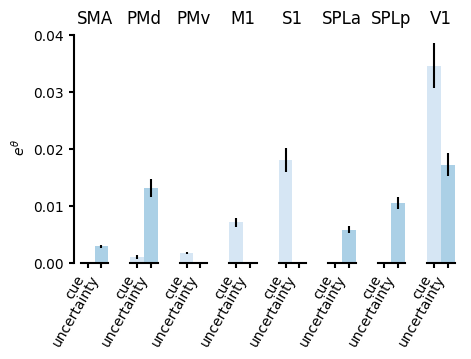

In [21]:
rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']
glm = 14
Hem = 'L'
experiment = 'smp2'

M, idx = find_model(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'M.plan.glm{glm}.pkl'), 'component')
n_param = M.n_param
components = ['cue','uncertainty']

fig, axs = plt.subplots(1, len(rois), sharex=True, sharey=True, figsize=(5, 3),)

colors = sns.color_palette("Blues", n_colors=5)[:2]

for r, roi in enumerate(rois):

    f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_cv.plan.glm{glm}.{Hem}.{roi}.pkl'), "rb")
    theta = np.exp(pickle.load(f)[idx][:n_param])

    theta_avg = theta.mean(axis=1)
    theta_err = theta.std(axis=1) / np.sqrt(theta.shape[1])

    axs[r].bar(components, theta_avg, width=1, facecolor=colors, yerr=theta_err,)
    axs[r].set_xticks(axs[r].get_xticks())
    axs[r].set_xticklabels(axs[r].get_xticklabels(), rotation=60, ha='right')

    axs[r].set_title(roi)

    axs[r].spines[['bottom',]].set_bounds(-.5, 1.5)
    axs[r].spines[['left',]].set_bounds(0, .04)
    axs[r].set_xlim(-1, 2)

    if r == 0:
        axs[r].set_ylabel(r'$e^{\theta}$')
        axs[r].spines[['top', 'right',]].set_visible(False)
        set_spines_and_ticks_width(axs[r], spine_width=1.5,spine_sides=('left', 'bottom',), tick_width=1.5,axes=('x', 'y'),which='both')
    else:
        axs[r].spines[['top', 'right','left']].set_visible(False)
        set_spines_and_ticks_width(axs[r], tick_width=0, axes='y')
        set_spines_and_ticks_width(axs[r], spine_width=1.5,spine_sides=('bottom',), tick_width=1.5,axes='x',which='both')

plt.show()

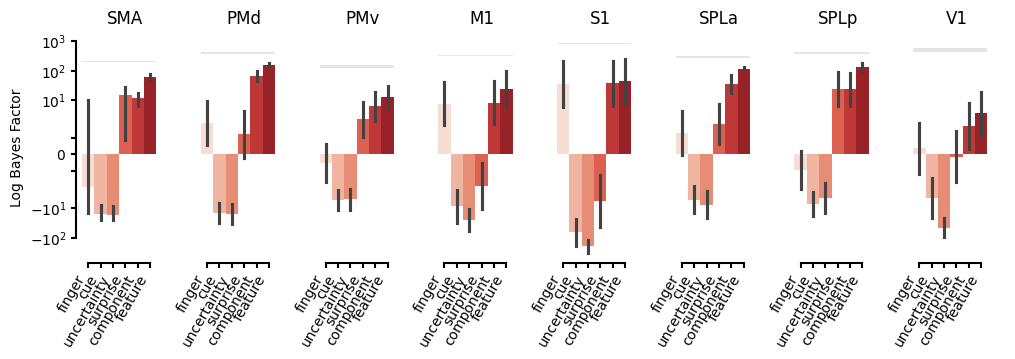

In [17]:
rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']
glm = 12
Hem = 'L'
experiment = 'smp2'

fig, axs = plt.subplots(1, len(rois), figsize=(12, 3), sharex=True, sharey=True)

colors = sns.color_palette("Reds", n_colors=5)

LL = pd.DataFrame()
for r, roi in enumerate(rois):

    T_cv = pd.read_pickle(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T_cv.exec.glm{glm}.{Hem}.{roi}.pkl'))
    T_gr = pd.read_pickle(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T_gr.exec.glm{glm}.{Hem}.{roi}.pkl'))

    plt.sca(axs[r])
    ax = pcm.model_plot(T_cv.likelihood,
                    null_model = 'null',
                    noise_ceiling= 'ceil',
                    upper_ceiling = T_gr.likelihood['ceil'],
                    width=1,
                    palette='Reds',
                    errorbar='se',)
    ax.set_title(roi)
    ax.set_xlabel('')
    ax.set_yscale('symlog')
    ax.spines[['bottom',]].set_bounds(0, 5)
    ax.spines[['left',]].set_bounds(-10**2, 10**3)
    ax.set_yticks([ -100, -10, 0, 10, 100, 1000])
    ax.set_xlim(-1, 7)
    ax.set_xticks(ax.get_xticks())
    ax.set_xticklabels(ax.get_xticklabels(), rotation=60, ha='right')

    if r == 0:
        ax.spines[['top', 'right',]].set_visible(False)
        set_spines_and_ticks_width(ax, spine_width=1.5,spine_sides=('left', 'bottom',), tick_width=1.5,axes=('x', 'y'),which='both')
    else:
        ax.spines[['top', 'right','left']].set_visible(False)
        set_spines_and_ticks_width(ax, tick_width=0, axes='y')
        set_spines_and_ticks_width(ax, spine_width=1.5,spine_sides=('bottom',), tick_width=1.5,axes='x',which='both')

plt.show()

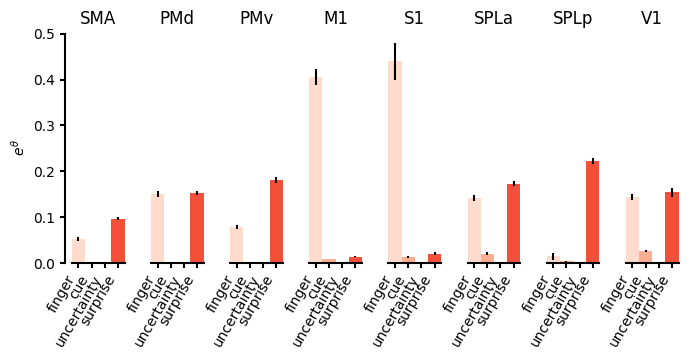

In [20]:
rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']
glm = 12
Hem = 'L'
experiment = 'smp2'

M, idx = find_model(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'M.exec.glm{glm}.pkl'), 'component')
n_param = M.n_param
components = ['finger', 'cue','uncertainty', 'surprise']

fig, axs = plt.subplots(1, len(rois), sharex=True, sharey=True, figsize=(8, 3),)

colors = sns.color_palette("Reds", n_colors=6)[:4]

for r, roi in enumerate(rois):

    f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_cv.exec.glm{glm}.{Hem}.{roi}.pkl'), "rb")
    theta = np.exp(pickle.load(f)[idx][:n_param])

    theta_avg = theta.mean(axis=1)
    theta_err = theta.std(axis=1) / np.sqrt(theta.shape[1])

    axs[r].bar(components, theta_avg, width=1, facecolor=colors, yerr=theta_err,)
    axs[r].set_xticks(axs[r].get_xticks())
    axs[r].set_xticklabels(axs[r].get_xticklabels(), rotation=60, ha='right')

    axs[r].set_title(roi)

    axs[r].spines[['bottom',]].set_bounds(-.5, 3.5)
    axs[r].spines[['left',]].set_bounds(0, .5)
    axs[r].set_xlim(-1, 4)

    if r == 0:
        axs[r].set_ylabel(r'$e^{\theta}$')
        axs[r].spines[['top', 'right',]].set_visible(False)
        set_spines_and_ticks_width(axs[r], spine_width=1.5,spine_sides=('left', 'bottom',), tick_width=1.5,axes=('x', 'y'),which='both')
    else:
        axs[r].spines[['top', 'right','left']].set_visible(False)
        set_spines_and_ticks_width(axs[r], tick_width=0, axes='y')
        set_spines_and_ticks_width(axs[r], spine_width=1.5,spine_sides=('bottom',), tick_width=1.5,axes='x',which='both')

plt.show()

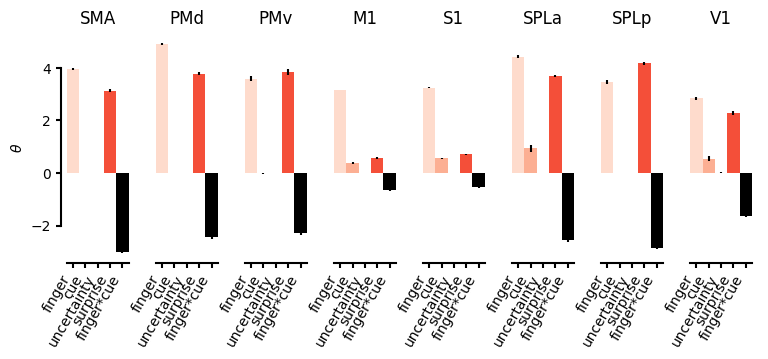

In [37]:
rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']
glm = 12
Hem = 'L'
experiment = 'smp2'

M, idx = find_model(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'M.exec.glm{glm}.pkl'), 'feature')
n_param = M.n_param
features = ['finger', 'cue','uncertainty', 'surprise', 'finger*cue']

fig, axs = plt.subplots(1, len(rois), sharex=True, sharey=True, figsize=(9, 3),)

colors = sns.color_palette("Reds", n_colors=6)[:4] + [(0, 0, 0)]

for r, roi in enumerate(rois):

    f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_cv.exec.glm{glm}.{Hem}.{roi}.pkl'), "rb")
    theta = pickle.load(f)[idx] #[:n_param]
    theta_param = theta[:n_param]
    # theta_param[:n_param - 1] = theta_param[:n_param - 1] ** 2
    # theta_param[n_param - 1] = theta_param[n_param - 1] * theta_param[0]
    # theta_scal = theta[n_param]
    # theta_param = theta_param * theta_scal

    theta_avg = theta_param.mean(axis=1)
    theta_err = theta_param.std(axis=1) / np.sqrt(theta_param.shape[1])

    axs[r].bar(features, theta_avg, width=1,yerr=theta_err,facecolor=colors,)
    axs[r].set_xticks(axs[r].get_xticks())
    axs[r].set_xticklabels(axs[r].get_xticklabels(), rotation=60, ha='right')

    axs[r].set_title(roi)

    axs[r].spines[['bottom',]].set_bounds(-.5, 4.5)
    axs[r].spines[['left',]].set_bounds(-2, 4)
    axs[r].set_xlim(-1, 5)

    if r == 0:
        axs[r].set_ylabel(r'$\theta$')
        axs[r].spines[['top', 'right',]].set_visible(False)
        set_spines_and_ticks_width(axs[r], spine_width=1.5,spine_sides=('left', 'bottom',), tick_width=1.5,axes=('x', 'y'),which='both')
    else:
        axs[r].spines[['top', 'right','left']].set_visible(False)
        set_spines_and_ticks_width(axs[r], tick_width=0, axes='y')
        set_spines_and_ticks_width(axs[r], spine_width=1.5,spine_sides=('bottom',), tick_width=1.5,axes='x',which='both')

plt.show()